# SME Credit Scoring Project

**Predicting SME loan default probability using alternative financial and behavioral data**

## 1. Project Introduction

**Business problem**: Small and Medium Enterprises (SMEs) often struggle to obtain loans because traditional credit-scoring systems rely heavily on collateral and formal credit histories. Fintech companies can use alternative financial signals such as GST returns, UPI transaction activity, bank transaction patterns, and cash-flow stability to better assess SME creditworthiness.

**Project goal**: Build an AI model that predicts loan default probability (risk score) to help financial institutions make better lending decisions and enable risk-based pricing and financial inclusion.

## 2. Load Dataset

Load the provided CSV dataset and display basic information. We will use `pandas` and `numpy`.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.6f}'.format
DATA_PATH = 'synthetic_sme_default_risk_dataset.csv'
assert os.path.exists(DATA_PATH), f'File not found: {DATA_PATH}'
df = pd.read_csv(DATA_PATH)

# first few rows
display(df.head())

# shape
print('Shape:', df.shape)

# column info
print('Column dtypes:')
print(df.dtypes)

# summary statistics
display(df.describe().T)

Matplotlib is building the font cache; this may take a moment.


,annual_revenue,monthly_transactions,avg_transaction_value,gst_compliance_score,upi_transaction_ratio,cashflow_stability,repayment_history_score,previous_loan_defaults,years_in_business,debt_to_revenue_ratio,default_probability
0,"5,745,071.229517",694.060079,"2,685.806323",0.694798,0.265902,0.711438,0.600690,0,1,0.564258,0.000694
1,"4,792,603.548243",686.646473,"3,133.400644",0.507554,0.427222,0.973360,0.626529,1,14,0.554506,0.001588
2,"5,971,532.807151",351.089207,"2,783.142727",0.949137,0.256402,0.372505,0.825298,0,5,0.824724,0.001023
3,"7,284,544.784612",717.477452,"3,632.501656",0.763522,0.870056,0.385101,0.957626,1,9,0.950569,0.001021
4,"4,648,769.937915",983.207270,"4,936.614238",0.924901,0.223601,0.791231,0.829720,2,9,1.184534,0.001258


Shape: (5000, 11)
Column dtypes:
annual_revenue             float64
monthly_transactions       float64
avg_transaction_value      float64
gst_compliance_score       float64
upi_transaction_ratio      float64
cashflow_stability         float64
repayment_history_score    float64
previous_loan_defaults       int64
years_in_business            int64
debt_to_revenue_ratio      float64
default_probability        float64
dtype: object


,count,mean,std,min,25%,50%,75%,max
annual_revenue,"5,000.000000","5,008,415.275333","1,494,679.652078","200,000.000000","4,013,142.443513","5,020,198.387843","5,999,015.910578","10,889,356.559654"
monthly_transactions,"5,000.000000",797.716236,251.999535,50.000000,628.354275,795.637369,969.309516,"1,682.263797"
avg_transaction_value,"5,000.000000","3,514.015284","1,194.520438",200.000000,"2,706.936358","3,511.900935","4,310.641099","7,614.692574"
gst_compliance_score,"5,000.000000",0.755085,0.144735,0.500024,0.631697,0.755897,0.880052,0.999950
upi_transaction_ratio,"5,000.000000",0.494410,0.228026,0.100088,0.296615,0.495608,0.684863,0.899756
cashflow_stability,"5,000.000000",0.648443,0.202255,0.300004,0.472095,0.649893,0.820927,0.999853
repayment_history_score,"5,000.000000",0.699243,0.172897,0.400059,0.550233,0.700031,0.848460,0.999561
previous_loan_defaults,"5,000.000000",0.390800,0.645414,0.000000,0.000000,0.000000,1.000000,5.000000
years_in_business,"5,000.000000",7.493600,4.027009,1.000000,4.000000,7.000000,11.000000,14.000000
debt_to_revenue_ratio,"5,000.000000",0.650563,0.314885,0.100115,0.380264,0.658212,0.914508,1.199825


**Column descriptions (interpreted):**
- `annual_revenue`: Annual revenue of the SME (currency units).
- `monthly_transactions`: Monthly transaction volume (count).
- `avg_transaction_value`: Average value per transaction.
- `gst_compliance_score`: GST filing/compliance score (0-1).
- `upi_transaction_ratio`: Ratio of transactions via UPI (0-1).
- `cashflow_stability`: Measure of cashflow variability (higher is more stable).
- `repayment_history_score`: Historical repayment behaviour score (0-1).
- `previous_loan_defaults`: Count of prior loan defaults.
- `years_in_business`: Firm age in years.
- `debt_to_revenue_ratio`: Liability scale relative to revenue.
- `default_probability`: Target variable (probability of default between 0 and 1).

## 3. Data Cleaning and Preprocessing

We'll check for missing values, duplicates, detect outliers, scale numerical features, and analyze correlations. Explanations accompany each step.

In [2]:
# 3.1 Missing values
missing = df.isnull().sum()
display(missing[missing>0])

# 3.2 Duplicates
n_dup = df.duplicated().sum()
print('Duplicate rows:', n_dup)
if n_dup>0:
    df = df.drop_duplicates().reset_index(drop=True)

# 3.3 Outlier detection using IQR for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('default_probability')
outlier_counts = {}
for c in numeric_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outlier_counts[c] = ((df[c] < lower) | (df[c] > upper)).sum()
print('Outlier counts (IQR method):')
print(outlier_counts)

# We'll winsorize extreme values at 1st and 99th percentiles to limit effect of outliers
for c in numeric_cols:
    lower_clip = df[c].quantile(0.01)
    upper_clip = df[c].quantile(0.99)
    df[c] = df[c].clip(lower_clip, upper_clip)

print('Applied 1%-99% clipping to numeric features to reduce outlier impact.')

Series([], dtype: int64)

Duplicate rows: 0
Outlier counts (IQR method):
{'annual_revenue': np.int64(42), 'monthly_transactions': np.int64(34), 'avg_transaction_value': np.int64(47), 'gst_compliance_score': np.int64(0), 'upi_transaction_ratio': np.int64(0), 'cashflow_stability': np.int64(0), 'repayment_history_score': np.int64(0), 'previous_loan_defaults': np.int64(54), 'years_in_business': np.int64(0), 'debt_to_revenue_ratio': np.int64(0)}
Applied 1%-99% clipping to numeric features to reduce outlier impact.


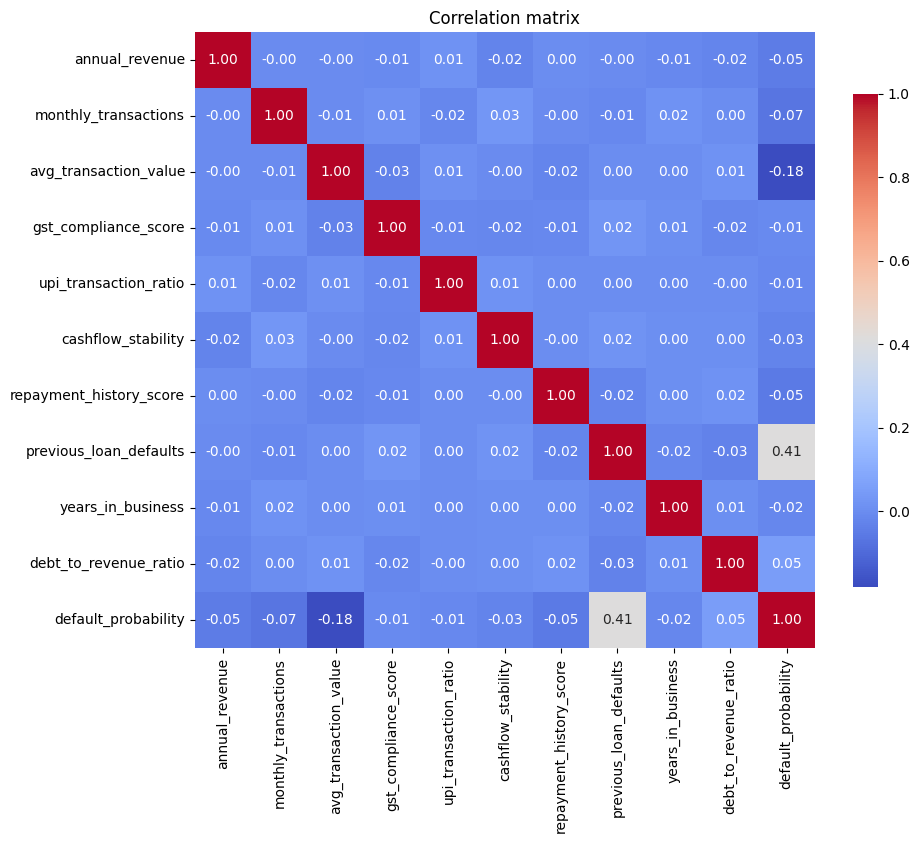

In [3]:
# 3.4 Correlation analysis
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'shrink':.8})
plt.title('Correlation matrix')
plt.show()

**Feature scaling**: For clustering and some ML models we scale numeric features using `StandardScaler`. Scaling preserves relationships but puts features on comparable ranges.

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_cols = numeric_cols + ['debt_to_revenue_ratio'] if 'debt_to_revenue_ratio' in df.columns else numeric_cols
X_scaled = df[scale_cols].copy()
X_scaled[scale_cols] = scaler.fit_transform(X_scaled[scale_cols])
display(X_scaled.head())

,annual_revenue,monthly_transactions,avg_transaction_value,gst_compliance_score,upi_transaction_ratio,cashflow_stability,repayment_history_score,previous_loan_defaults,years_in_business,debt_to_revenue_ratio,debt_to_revenue_ratio
0,0.503118,-0.418262,-0.703541,-0.416865,-1.002855,0.311653,-0.570284,-0.609486,-1.612673,-0.274287,-0.274287
1,-0.146675,-0.448182,-0.322881,-1.711379,-0.294849,1.607445,-0.420752,0.954903,1.615852,-0.305284,-0.305284
2,0.657614,-1.802446,-0.620761,1.341511,-1.044551,-1.365134,0.729543,-0.609486,-0.619281,0.553538,0.553538
3,1.553378,-0.323753,0.101584,0.058262,1.648683,-1.302818,1.495342,0.954903,0.374112,0.953505,0.953505
4,-0.244802,0.748697,1.210677,1.173959,-1.188508,0.706409,0.755139,2.519291,0.374112,1.697106,1.697106


## 4. Exploratory Data Analysis (EDA)

Visualizations to understand financial behavior and risk factors.

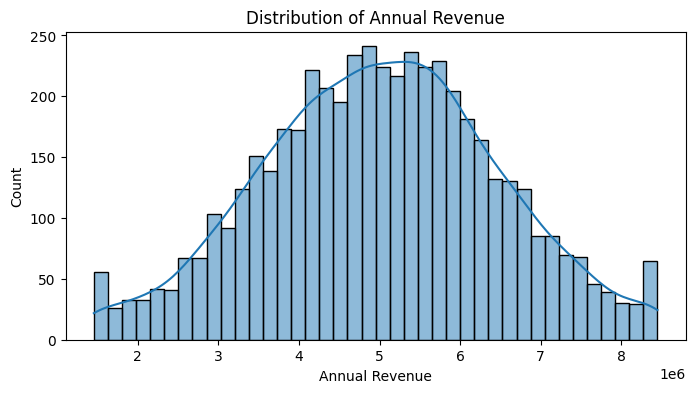

In [5]:
# Distribution of annual revenue
plt.figure(figsize=(8,4))
sns.histplot(df['annual_revenue'], bins=40, kde=True)
plt.title('Distribution of Annual Revenue')
plt.xlabel('Annual Revenue')
plt.show()

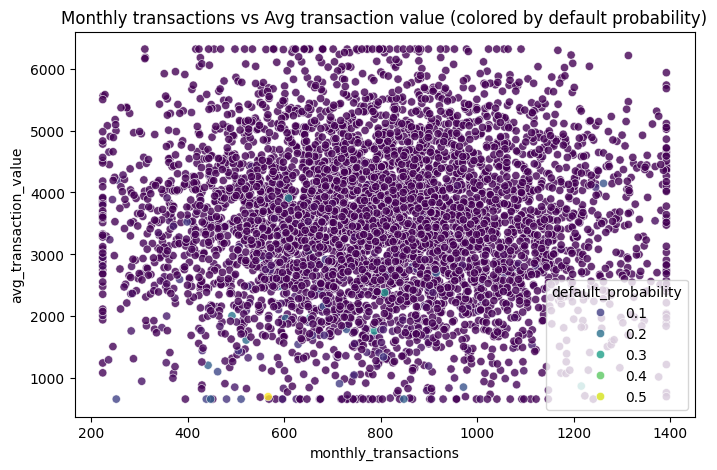

In [6]:
# Transaction volume analysis: monthly transactions vs avg transaction value
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='monthly_transactions', y='avg_transaction_value', hue='default_probability', palette='viridis', alpha=0.8)
plt.title('Monthly transactions vs Avg transaction value (colored by default probability)')
plt.show()

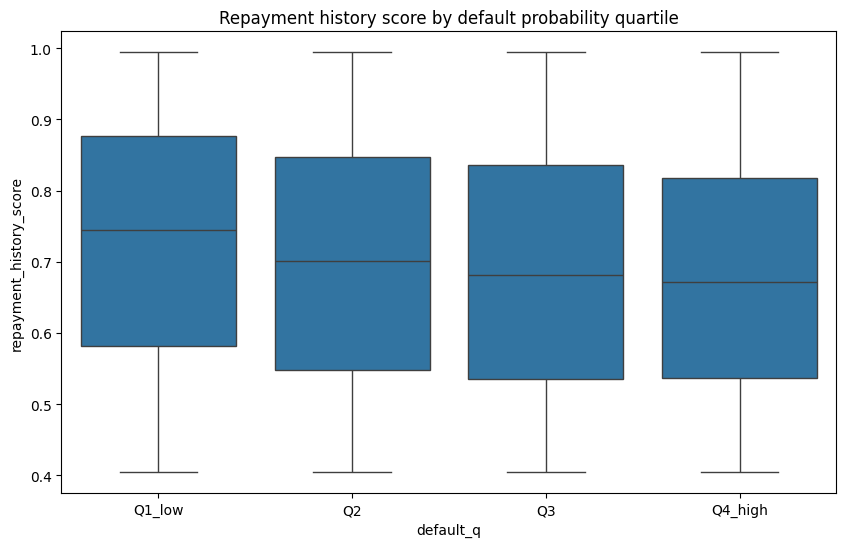

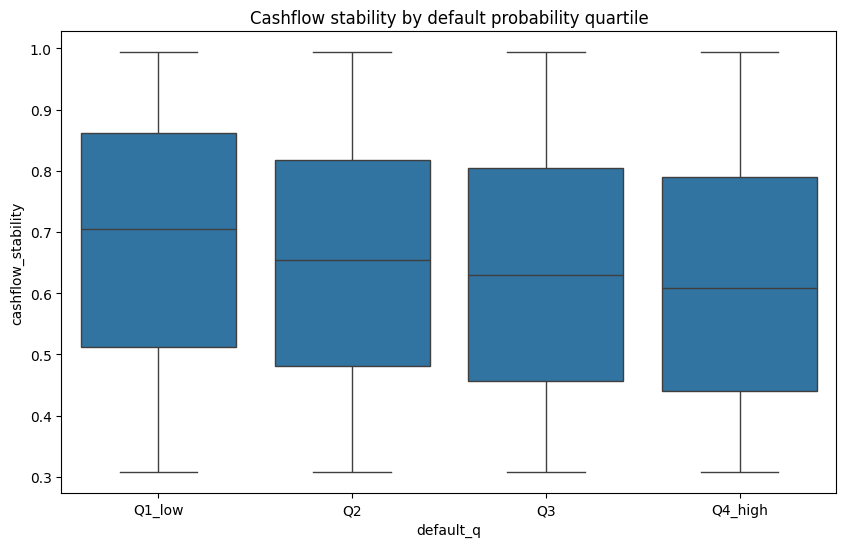

In [7]:
# Box plots showing how features vary with default probability quantiles
df['default_q'] = pd.qcut(df['default_probability'], q=4, duplicates='drop', labels=['Q1_low','Q2','Q3','Q4_high'])
plt.figure(figsize=(10,6))
sns.boxplot(x='default_q', y='repayment_history_score', data=df)
plt.title('Repayment history score by default probability quartile')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='default_q', y='cashflow_stability', data=df)
plt.title('Cashflow stability by default probability quartile')
plt.show()

**Insights (example)**: Higher `repayment_history_score` and `cashflow_stability` typically associate with lower `default_probability`. Transaction patterns (higher stable transaction volumes) often indicate healthier SMEs. Correlations above help identify which signals are most predictive.

## 5. SME Segmentation using K-Means Clustering

We segment SMEs into financial profiles (Low/Medium/High risk) using K-Means on selected features.

In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# select features for clustering
cluster_features = ['annual_revenue','monthly_transactions','avg_transaction_value','cashflow_stability','repayment_history_score','debt_to_revenue_ratio','upi_transaction_ratio']
cluster_features = [c for c in cluster_features if c in df.columns]
X_cluster = df[cluster_features].copy()
X_cluster_scaled = scaler.transform(X_cluster)

# Elbow method
inertias = []
K_RANGE = range(1,11)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K_RANGE), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for optimal k')
plt.xticks(list(K_RANGE))
plt.show()

# Choose k=3 for Low/Medium/High risk segmentation (justify with elbow)
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)
df['cluster'] = clusters

# Visualize clusters with PCA to 2D
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X_cluster_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=proj[:,0], y=proj[:,1], hue=df['cluster'], palette='tab10')
plt.title('KMeans clusters (PCA projection)')
plt.show()

# Map clusters to risk labels based on average default probability
cluster_default = df.groupby('cluster')['default_probability'].mean().sort_values()
cluster_default

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- gst_compliance_score
- previous_loan_defaults
- years_in_business


In [ ]:
# Assign semantic risk labels: lowest mean default -> Low Risk, middle -> Medium, highest -> High
order = cluster_default.index.tolist()
label_map = {order[0]:'Low Risk', order[1]:'Medium Risk', order[2]:'High Risk'}
df['risk_segment'] = df['cluster'].map(label_map)
df[['cluster','risk_segment']].value_counts()

# Show mean default probabilities per segment
display(df.groupby('risk_segment')['default_probability'].agg(['count','mean','std']).sort_values('mean'))

**Business interpretation of clusters:**
- Low Risk SMEs: Higher repayment scores, stable cashflow, lower debt-to-revenue; good candidates for larger or cheaper loans.
- Medium Risk SMEs: Mixed signals; may require collateral or priced loans.
- High Risk SMEs: Higher default probability, poor repayment history or unstable cashflow; eligible for small-ticket loans or rejection.

## 6. Regression Model Implementation (Linear Regression)

We train a linear regression model to predict `default_probability`. We'll evaluate using R² and MSE.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Prepare features and target
feature_cols = ['annual_revenue','monthly_transactions','avg_transaction_value','gst_compliance_score','upi_transaction_ratio','cashflow_stability','repayment_history_score','previous_loan_defaults','years_in_business','debt_to_revenue_ratio']
feature_cols = [c for c in feature_cols if c in df.columns]
X = df[feature_cols].copy()
y = df['default_probability'].copy()

# Scale numeric features (reuse scaler fitted earlier)
X_scaled = scaler.transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Linear Regression MSE: {mse:.6e}')
print(f'Linear Regression R2: {r2:.4f}')

# Save model and scaler for deployment
os.makedirs('models', exist_ok=True)
joblib.dump(lr, 'models/linear_regression_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print('Saved trained Linear Regression model and scaler to models/ (models/linear_regression_model.pkl, models/scaler.pkl)')

## 7. Business Interpretation of Results

Explain how the model and findings tie to credit risk management, financial stability indicators, loan demand and pricing strategy for banks and fintechs.

**Key points for stakeholders:**
- **Credit risk management**: The model identifies variables (e.g., repayment history, cashflow stability, debt-to-revenue) that are predictive of default. Lenders can use the predicted probability as an input to approval and pricing decisions.
- **Financial stability indicators**: Stable cashflow and consistent transaction volumes lower risk; such SMEs can access larger credit lines.
- **SME loan demand**: By segmenting SMEs, lenders can design tailored products (invoice financing, working capital loans) matching SME profiles.
- **Revenue optimization for banks**: Risk-based pricing (higher rates for higher predicted default probability) balances portfolio yield and risk.
- **Loan pricing strategy**: Use predicted risk scores to tier interest rates, collateral requirements, or monitoring intensity.
- **Risk-based lending decisions**: Combine model output with human underwriting to reduce false rejections and widen financial inclusion.

## 8. Conclusion

- AI models using alternative financial data can significantly improve SME credit assessments beyond traditional credit bureau signals.
- Alternative data (transaction patterns, cashflow stability, repayment behaviour) enables more nuanced risk scoring and supports financial inclusion for underbanked SMEs.
- Deploying such models in production requires governance: periodic retraining, bias monitoring, and integration with human oversight.

## 9. Streamlit Dashboard (app.py)

A companion Streamlit app is provided as `app.py`. It loads the trained model and scaler, accepts user inputs for SME financial features, and outputs predicted default probability and risk category.

**How to run the Streamlit app (locally):**
1. Ensure `models/linear_regression_model.pkl` and `models/scaler.pkl` exist (created by the notebook).
2. Install Streamlit: `pip install streamlit`
3. Run: `streamlit run app.py`